In [1]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
#from keras.layers.convolutional import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Conv2D, MaxPooling2D



In [2]:
train_path = 'datasets/train'
test_path = 'datasets/test'

In [3]:
activities = os.listdir(train_path)
num_classes = len(activities)
print(num_classes)

4


In [4]:
train_frames = []
train_labels = []
for i, activity in enumerate(activities):
    activity_path = os.path.join(train_path, activity)
    for video_file in os.listdir(activity_path):
        video_path = os.path.join(activity_path, video_file)
        cap = cv2.VideoCapture(video_path)
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            resized_frame = cv2.resize(frame, (64, 64))
            train_frames.append(resized_frame)
            train_labels.append(i)
        cap.release()

In [5]:
# Convert training frames and labels to numpy arrays
X_train = np.array(train_frames)
y_train = np.array(train_labels)

In [6]:
# Load testing video frames and labels
test_frames = []
test_labels = []
for i, activity in enumerate(activities):
    activity_path = os.path.join(test_path, activity)
    for video_file in os.listdir(activity_path):
        video_path = os.path.join(activity_path, video_file)
        cap = cv2.VideoCapture(video_path)
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            resized_frame = cv2.resize(frame, (64, 64))
            test_frames.append(resized_frame)
            test_labels.append(i)
        cap.release()
print("done")

done


In [7]:
# Convert testing frames and labels to numpy arrays
X_test = np.array(test_frames)
y_test = np.array(test_labels)

# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0
# Convert labels to one-hot vectors
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)


In [8]:
# Step 2: Define the model architecture
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(64, 64, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

C:\Users\shaka\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
# Step 3: Compile and train the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 254ms/step - accuracy: 0.6443 - loss: 0.9677 - val_accuracy: 0.9111 - val_loss: 0.4130
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 151ms/step - accuracy: 0.9068 - loss: 0.3650 - val_accuracy: 0.9862 - val_loss: 0.2005
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 151ms/step - accuracy: 0.9397 - loss: 0.1664 - val_accuracy: 0.9743 - val_loss: 0.0999
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 148ms/step - accuracy: 0.9651 - loss: 0.1168 - val_accuracy: 0.9684 - val_loss: 0.0687
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 190ms/step - accuracy: 0.9798 - loss: 0.0728 - val_accuracy: 0.9605 - val_loss: 0.1183
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 163ms/step - accuracy: 0.9597 - loss: 0.1167 - val_accuracy: 0.9783 - val_loss: 0.0497
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 163ms/step - accuracy: 0.9687 - loss: 0.0765 - val_accuracy: 0.9802 - val_loss: 0.1194
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 154ms/step - accuracy: 0.9688 - loss: 0.1163 - val_accuracy: 0

In [10]:
# Step 4: Save the trained model
model.save('violence1.h5')

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step
Training Accuracy: 99.62%
Training Precision: 0.99
Training Recall: 0.99
Training F1-score: 0.99


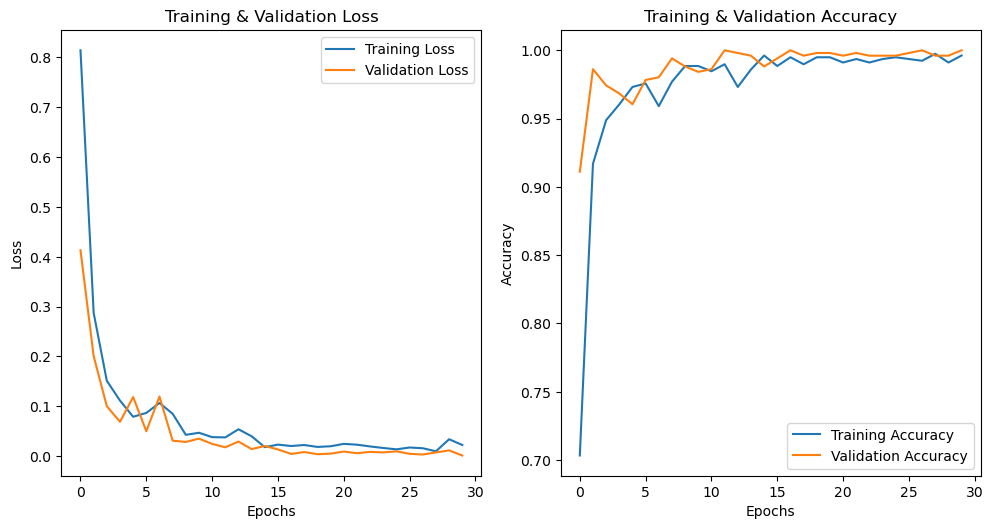

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import load_model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load the trained model
model = load_model('violence.h5')

# Assuming history was saved during model training (replace with actual path if applicable)
# history = model.history  # If you have the training history object

# Make predictions on the training data
y_train_pred = model.predict(X_train)
y_train_pred = np.argmax(y_train_pred, axis=1)

# Convert the true labels to their corresponding class index
y_train_true = np.argmax(y_train, axis=1)

# Calculate accuracy
train_accuracy = accuracy_score(y_train_true, y_train_pred)

# Calculate precision, recall, and F1-score
train_precision = precision_score(y_train_true, y_train_pred, average='macro')
train_recall = recall_score(y_train_true, y_train_pred, average='macro')
train_f1 = f1_score(y_train_true, y_train_pred, average='macro')

# Print the evaluation metrics
print(f'Training Accuracy: {train_accuracy * 100:.2f}%')
print(f'Training Precision: {train_precision:.2f}')
print(f'Training Recall: {train_recall:.2f}')
print(f'Training F1-score: {train_f1:.2f}')

# --- If you have history from training, plot accuracy, loss, precision, recall, and F1-score graphs ---
if 'history' in locals():
    # Plot training loss and accuracy
    plt.figure(figsize=(15, 10))

    # Subplot for Loss
    plt.subplot(2, 3, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Subplot for Accuracy
    plt.subplot(2, 3, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training & Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()



In [12]:
from sklearn.metrics import classification_report

# Load the trained model
model = load_model('violence.h5')

# Make predictions on the training data
y_train_pred = model.predict(X_train)
y_train_pred = np.argmax(y_train_pred, axis=1)

# Convert the true labels to their corresponding class index
y_train_true = np.argmax(y_train, axis=1)

# Generate classification report
train_report = classification_report(y_train_true, y_train_pred, target_names=activities)

# Print the classification report
print("Training Classification Report:")
print(train_report)


C:\Users\shaka\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step
Training Classification Report:
                    precision    recall  f1-score   support

human using weapon       1.00      1.00      1.00        77
      non_violence       1.00      1.00      1.00       529
   people fighting       1.00      1.00      1.00       127
             theft       0.96      0.98      0.97        49

          accuracy                           1.00       782
         macro avg       0.99      0.99      0.99       782
      weighted avg       1.00      1.00      1.00       782



C:\Users\shaka\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step


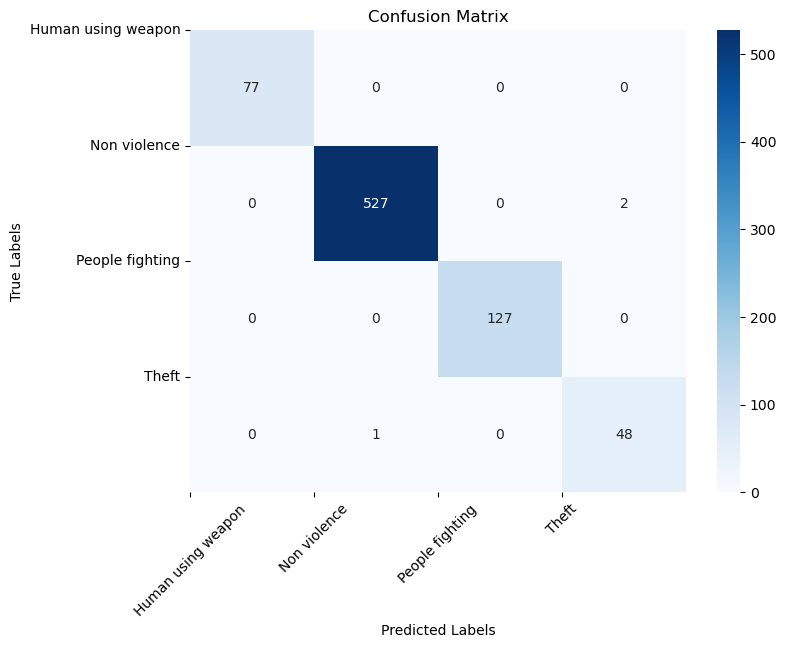

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt  # Correct the import statement for matplotlib
from tensorflow.keras.models import load_model  # Assuming you are using TensorFlow/Keras
import numpy as np

# Load the trained model
model = load_model('violence.h5')

# Make predictions on the training data
y_train_pred = model.predict(X_train)
y_train_pred = np.argmax(y_train_pred, axis=1)

# Convert the true labels to their corresponding class index
y_train_true = np.argmax(y_train, axis=1)

# Generate the confusion matrix
cm = confusion_matrix(y_train_true, y_train_pred)

# Define the class labels
class_labels = ['Human using weapon','Non violence','People fighting','Theft']  # Replace with your class labels

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

# Set labels for x-axis and y-axis
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

# Set x-tick and y-tick labels
plt.xticks(np.arange(len(class_labels)), class_labels, rotation=45)
plt.yticks(np.arange(len(class_labels)), class_labels, rotation=0)

# Set title for the plot
plt.title('Confusion Matrix')

# Show the plot
plt.show()


In [14]:
###Testing 

In [15]:
import cv2
import numpy as np
from keras.models import load_model

# Load the trained model
model = load_model('violence.h5')

# Define the activities (classes)
activities = ['Human using weapon','non violence','people fighting','theft'] # Replace with your actual activity labels

# Load the test video
test_video_path = 'p4.mp4'  # Replace with the path to your test video
cap = cv2.VideoCapture(test_video_path)

# Get the video properties
frame_width = int(cap.get(3))
frame_height = int(cap.get(4))
fps = cap.get(cv2.CAP_PROP_FPS)

# Create an output video writer
output_video_path = 'predicted_video.mp4'  # Replace with the desired output video path
fourcc = cv2.VideoWriter_fourcc(*'MJPG')
out = cv2.VideoWriter(output_video_path, fourcc, fps, (frame_width, frame_height))

# Read the video frames
while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Preprocess the frame (resize and normalize)
    resized_frame = cv2.resize(frame, (64, 64))
    normalized_frame = resized_frame / 255.0

    # Add the batch dimension
    input_frame = np.expand_dims(normalized_frame, axis=0)

    # Make prediction on the input frame
    pred = model.predict(input_frame)
    pred_label = np.argmax(pred)
    activity = activities[pred_label]

    # Draw the predicted activity label on the frame
    cv2.putText(frame, activity, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0 , 255), 2)

    # Write the frame to the output video
    out.write(frame)

    # Display the frame with labeled activity
    cv2.imshow('Predicted Video', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the video capture and output video writer
cap.release()
out.release()

# Destroy all OpenCV windows
cv2.destroyAllWindows()

C:\Users\shaka\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1